# Reproducing if_bregman (Fig. 1 / Table corr_inf) + approximator comparison

**Goal.** Reproduce the paper's result: for a trained MLP, the influence-function
estimate of the test-loss change from deleting a training point correlates
**poorly with warm-start retraining** but **well with the PBRF**. Then swap the
curvature $\hat G_M$ to see whether a "better Hessian" tracks the PBRF better.

**Setup** (small enough that the dense GNH is feasible): Energy (UCI) regression,
2-hidden-layer MLP (width 64), MSE, SGD — trained with the repo's `train_model`.
Two retraining ground truths from $\theta^s$ ($K/2$ epochs, minibatch SGD):
warm-start (real loss, point removed) and PBRF (Bregman objective, lr $/10$).
Prediction: $\tfrac1N[(\hat G_M+\lambda I)^{-1}\nabla\phi_Q]^\top\nabla\ell(z)$ via
the repo's GNH/Kronecker computers + influence tools.

*Why these knobs:* an over-converged model gives a near-singular GNH and a tiny,
noisy PBRF signal (correlations collapse). Moderate training (300 epochs) + a
little weight decay keep the GNH well-conditioned, and $\lambda=0.01$ stabilises
the exact inverse (the paper uses LiSSA, which is implicitly damped).

## Setup

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
import sys
from pathlib import Path

PROJECT_ROOT = Path("/root/Hessian-Approximation-for-Toy-Models")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp, numpy as np, optax, pandas as pd, tempfile
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree
from scipy.stats import pearsonr, spearmanr

from src.config import (
    ModelConfig,
    TrainingConfig,
    ModelArchitecture,
    ActivationFunction,
    LossType,
    OptimizerType,
    LRSchedule,
    DatasetEnum,
    PseudoTargetGenerationStrategy as PTS,
    HessianApproximationMethod as HAM,
)
from src.utils.data.data import DownloadableDataset, normalize_for_loss, Dataset
from src.utils.train import train_model
from src.utils.optimizers import optimizer as make_optimizer
from src.utils.loss import get_loss, loss_wrapper_with_apply_fn
from src.hessians.collector import CollectorActivationsGradients
from src.hessians.computer.registry import HessianComputerRegistry
from src.hessians.utils.data import ModelContext
from src.utils.influence import compute_per_example_flat_grads, compute_influence_matrix

print("jax", jax.__version__, "| x64:", jax.config.jax_enable_x64)

INFO:2026-06-23 20:53:49,070:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


INFO:2026-06-23 20:53:49,%f:xla_bridge.py:backends:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
jax 0.8.2 | x64: True


## Config

In [2]:
DATASET = "energy"
HIDDEN = 64
EPOCHS = 300  # moderate: avoids the over-converged / singular-GNH regime
LR = 0.05
BATCH = 32
WD = 1e-3  # light weight decay -> well-conditioned GNH
LAMBDA = 1e-2  # damping (stabilises the exact inverse; ~ LiSSA implicit damping)
PBRF_LR = LR / 10.0  # paper decays the lr by 10x for PBRF
N_DELETED = 40
RETRAIN_EPOCHS = EPOCHS // 2
SEED = 0
RETRAIN_KEY = 7
METHODS = [HAM.GNH, HAM.KFAC, HAM.EKFAC, HAM.SHAMPOO, HAM.ESHAMPOO, HAM.IDENTITY]

## Load data + train base model $\theta^s$ (repo `train_model`)

In [3]:
loss_fn = get_loss(LossType.MSE)
full = DownloadableDataset.load(
    DatasetEnum(DATASET),
    directory=str(PROJECT_ROOT / f"experiments/datasets/{DATASET}"),
    store_on_disk=False,
)
tr_raw, te_raw = full.train_test_split(test_size=0.15, seed=42)
train_ds, test_ds = normalize_for_loss(
    tr_raw, te_raw, LossType.MSE
)  # StandardScaler for MSE
X = jnp.asarray(train_ds.inputs, jnp.float64)
Y = jnp.asarray(train_ds.targets, jnp.float64)
Xq = jnp.asarray(test_ds.inputs, jnp.float64)
Yq = jnp.asarray(test_ds.targets, jnp.float64)
N, IN, OUT = int(X.shape[0]), int(X.shape[1]), int(Y.shape[1])

model_config = ModelConfig(
    architecture=ModelArchitecture.MLP,
    input_dim=IN,
    hidden_dim=[HIDDEN, HIDDEN],
    output_dim=OUT,
    activation=ActivationFunction.RELU,
    loss=LossType.MSE,
    training=TrainingConfig(
        learning_rate=LR,
        weight_decay=WD,
        optimizer=OptimizerType.SGD,
        epochs=EPOCHS,
        batch_size=BATCH,
        lr_schedule=LRSchedule.NONE,
    ),
    directory=None,
)
opt = make_optimizer(
    OptimizerType.SGD, lr=LR, weight_decay=WD, lr_schedule=LRSchedule.NONE
)
dl = train_ds.get_dataloader(batch_size=BATCH, shuffle=True, seed=0)
model, params, _ = train_model(
    model_config, dl, loss_fn, opt, epochs=EPOCHS, seed=0, save_checkpoints=False
)
params = jax.tree.map(lambda x: jnp.asarray(x, jnp.float64), params)
flat_params_s, unravel = ravel_pytree(params)
EPS = 1.0 / N
print(
    f"N_train={N} in={IN} out={OUT} params={flat_params_s.size}  "
    f"train_loss={float(loss_fn(model.apply(params, X), Y)):.4f} test_loss={float(loss_fn(model.apply(params, Xq), Yq)):.4f}"
)

INFO:2026-06-23 20:53:53,%f:train.py:initialize_model:257: Device for Parameters: {CudaDevice(id=0)}


 15%|█▌        | 46/300 [00:03<00:07, 35.92it/s]

INFO:2026-06-23 20:53:57,%f:train.py:train_model:140: Epoch 50, Loss: 0.0085, Grad Norm: 0.204419


 32%|███▏      | 95/300 [00:04<00:03, 58.97it/s]

INFO:2026-06-23 20:53:58,%f:train.py:train_model:140: Epoch 100, Loss: 0.0062, Grad Norm: 0.215332


...

INFO:2026-06-23 20:54:00,%f:train.py:train_model:140: Epoch 250, Loss: 0.0066, Grad Norm: 0.399355


 97%|█████████▋| 292/300 [00:07<00:00, 71.27it/s]

INFO:2026-06-23 20:54:01,%f:train.py:train_model:140: Epoch 300, Loss: 0.0061, Grad Norm: 0.221999


100%|██████████| 300/300 [00:07<00:00, 40.18it/s]


N_train=652 in=8 out=2 params=4736  train_loss=0.0050 test_loss=0.0070


## Frozen targets, deleted points, $\phi_Q$, per-example MSE / Bregman

In [4]:
soft_targets = jax.lax.stop_gradient(model.apply(params, X))
rng = np.random.RandomState(SEED)
deleted_idx = jnp.asarray(rng.choice(N, N_DELETED, replace=False), dtype=jnp.int32)


def phi_Q_flat(fp):
    return loss_wrapper_with_apply_fn(model.apply, fp, unravel, loss_fn, Xq, Yq)


phi0 = float(phi_Q_flat(flat_params_s))
loss_per = lambda f, y: jnp.mean((f - y) ** 2, -1)  # per-example MSE
breg_per = lambda f, fs: jnp.mean(
    (f - jax.lax.stop_gradient(fs)) ** 2, -1
)  # MSE Bregman to frozen output
print(f"phi_Q(theta^s) = {phi0:.5f}")

phi_Q(theta^s) = 0.00705


## Ground truths — warm-start and PBRF retraining

Minibatch SGD from $\theta^s$ for $K/2$ epochs, deleted point masked per-example,
`vmap`ed over the 40 points. Warm = real loss with the point removed (base lr);
PBRF = Bregman + prox $-\tfrac1N\ell(z)$ (lr$/10$).

In [5]:
def retrain(mode, lr, lam):
    o = optax.sgd(lr)
    nfull = N // BATCH

    def one(t):
        def bl(p, idx):
            f = model.apply(unravel(p), X[idx])
            is_t = (idx == t).astype(f.dtype)
            if mode == "warm":
                c = (1.0 - is_t) * loss_per(f, Y[idx])
                return jnp.sum(c) / jnp.maximum(jnp.sum(1.0 - is_t), 1.0)
            c = (1.0 - is_t) * breg_per(f, soft_targets[idx]) + is_t * (
                -loss_per(f, Y[idx])
            )
            return jnp.mean(c) + 0.5 * lam * jnp.sum((p - flat_params_s) ** 2)

        def ep(carry, ek):
            p, st = carry
            perm = jax.random.permutation(ek, N)[: nfull * BATCH].reshape(nfull, BATCH)

            def bs(c, idx):
                p, st = c
                g = jax.grad(bl)(p, idx)
                u, st = o.update(g, st, p)
                return (optax.apply_updates(p, u), st), None

            (p, st), _ = jax.lax.scan(bs, (p, st), perm)
            return (p, st), None

        keys = jax.random.split(jax.random.PRNGKey(RETRAIN_KEY), RETRAIN_EPOCHS)
        (p, _), _ = jax.lax.scan(ep, (flat_params_s, o.init(flat_params_s)), keys)
        return phi_Q_flat(p)

    return np.asarray(jax.jit(jax.vmap(one))(deleted_idx)) - phi0


delta_warm = retrain("warm", LR, 0.0)
delta_pbrf = retrain("pbrf", PBRF_LR, LAMBDA)
print(f"Delta_warm: mean={delta_warm.mean():+.2e} std={delta_warm.std():.2e}")
print(f"Delta_pbrf: mean={delta_pbrf.mean():+.2e} std={delta_pbrf.std():.2e}")

Delta_warm: mean=-2.38e-03 std=1.52e-05
Delta_pbrf: mean=+8.91e-06 std=3.82e-05


## Build curvatures + IF predictions (all methods)

In [6]:
model_ctx = ModelContext.create(
    model=model, params=params, dataset=train_ds, loss_fn=loss_fn
)
collector_data = CollectorActivationsGradients(
    model=model,
    params=params,
    loss_fn=loss_fn,
    pseudo_target_strategy=PTS.EMPIRICAL_FISHER,
    pseudo_target_repetitions=1,
).collect(
    dataset=Dataset(inputs=X, targets=Y),
    save_directory=tempfile.mkdtemp(),
    try_load=False,
    rng_key=jax.random.PRNGKey(42),
)

query_grad = jax.grad(phi_Q_flat)(flat_params_s)
train_grads = compute_per_example_flat_grads(
    model, params, X[deleted_idx], Y[deleted_idx], loss_fn
)
delta_if = {}
for m in METHODS:
    cc = HessianComputerRegistry.get_compute_context(m, collector_data, model_ctx)
    comp = HessianComputerRegistry.get_computer(
        m, cc, corr_context=collector_data
    ).build(base_directory=None)
    delta_if[m] = EPS * np.asarray(
        compute_influence_matrix(
            query_grad[None, :], train_grads, comp, damping=float(LAMBDA)
        )
    ).reshape(-1)
    print(f"built+scored {m.value}")

INFO:2026-06-23 20:54:05,%f:collector.py:_generate_pseudo_targets:202: [PSEUDO-TARGETS] EMPIRICAL_FISHER (ground-truth labels)
INFO:2026-06-23 20:54:05,%f:collector.py:_run_collection_loop:294: [COLLECTION] EMPIRICAL_FISHER: N=652, k=1
INFO:2026-06-23 20:54:06,%f:collector.py:_teardown:335: [TEARDOWN] EMPIRICAL_FISHER: activations (N=652, ...), gradients (N=652, ..., k=1)
INFO:2026-06-23 20:54:06,%f:collector.py:collect:150: Saving collected data to: /tmp/tmpd2kef9kz
INFO:2026-06-23 20:54:06,%f:collector.py:save:374: Saved collected data manifest to: /tmp/tmpd2kef9kz
INFO:2026-06-23 20:54:10,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 4736 params
built+scored gnh
INFO:2026-06-23 20:54:15,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 4736 params
built+scored kfac
INFO:2026-06-23 20:54:15,%f:influence.py:compute_influence_matrix:77: Computing IHVPs: 1 test × 4736 params
built+scored ekfac
INFO:2026-06-23 20:54:16,%f:influence.py:compute

## Reproduction (Fig. 1) — GNH-IF vs warm-start vs PBRF

The paper's result: IF is a *poor* match to warm-start retraining but a *good*
match to the PBRF. Left should scatter, right should hug the diagonal.

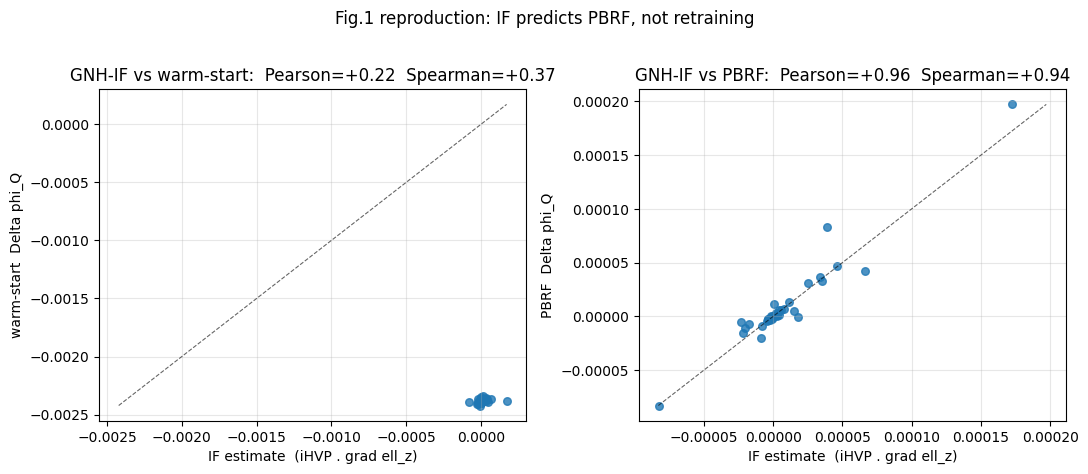

In [7]:
def _corr(a, b):
    return pearsonr(a, b)[0], spearmanr(a, b)[0]


pred = delta_if[HAM.GNH]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (gt, name) in zip(axes, [(delta_warm, "warm-start"), (delta_pbrf, "PBRF")]):
    p, s = _corr(pred, gt)
    ax.scatter(pred, gt, s=30, alpha=0.8)
    lo, hi = float(min(pred.min(), gt.min())), float(max(pred.max(), gt.max()))
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.6)
    ax.set_title(f"GNH-IF vs {name}:  Pearson={p:+.2f}  Spearman={s:+.2f}")
    ax.set_xlabel("IF estimate  (iHVP . grad ell_z)")
    ax.set_ylabel(f"{name}  Delta phi_Q")
    ax.grid(alpha=0.3)
fig.suptitle("Fig.1 reproduction: IF predicts PBRF, not retraining", y=1.02)
fig.tight_layout()
plt.show()

## Approximator comparison — does a better curvature track PBRF better?

In [8]:
rows = []
for m in METHODS:
    pP, pS = _corr(delta_if[m], delta_pbrf)
    wP, wS = _corr(delta_if[m], delta_warm)
    rows.append(
        dict(
            method=m.value,
            pbrf_P=pP,
            pbrf_S=pS,
            warm_P=wP,
            warm_S=wS,
            ratio=float(np.linalg.norm(delta_if[m]) / np.linalg.norm(delta_pbrf)),
        )
    )
res = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:+.3f}")
print(res.to_string(index=False))

  method  pbrf_P  pbrf_S  warm_P  warm_S   ratio
     gnh  +0.964  +0.944  +0.216  +0.372  +0.904
    kfac  +0.836  +0.500  +0.033  -0.047 +71.628
   ekfac  +0.834  +0.498  +0.010  -0.054 +67.519
 shampoo  +0.820  +0.507  -0.020  -0.055 +57.535
eshampoo  +0.819  +0.496  -0.037  -0.072 +56.243
identity  +0.759  +0.462  +0.107  +0.033  +1.626


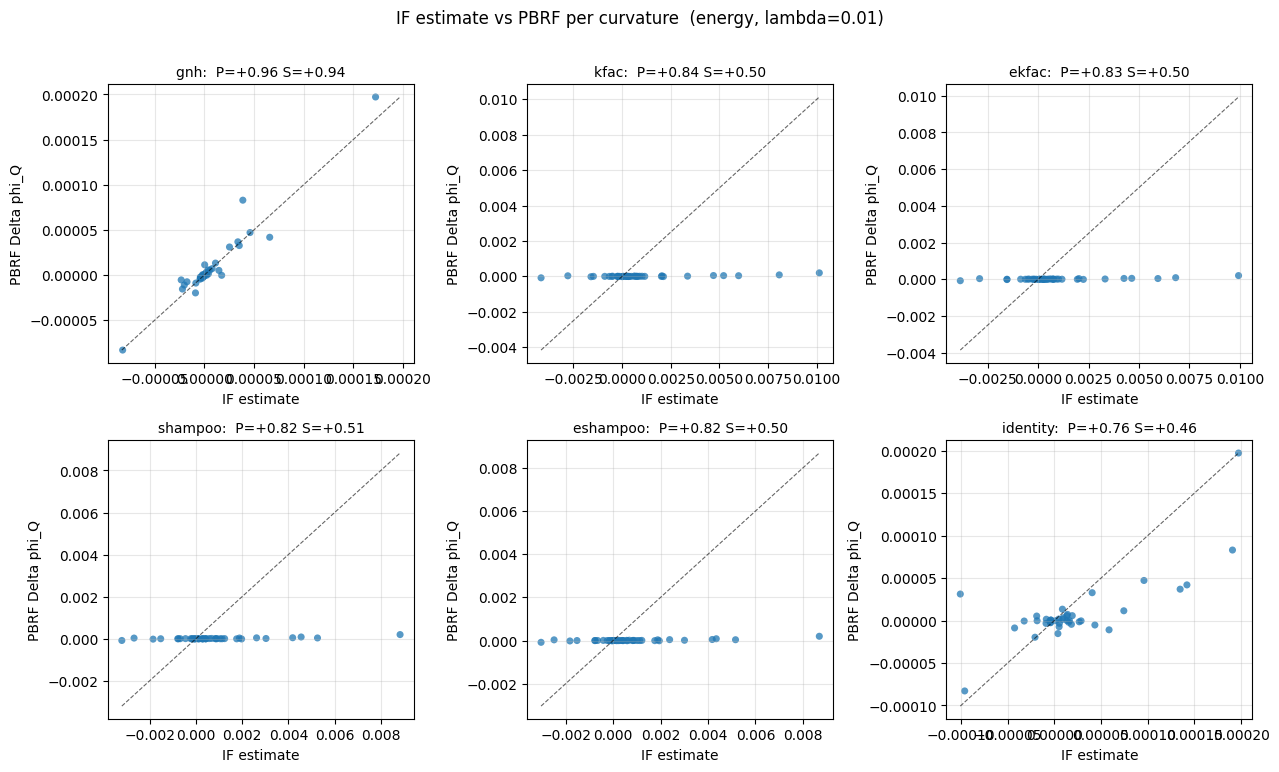

In [9]:
# scatter grid (Fig.1-style) per curvature, vs PBRF
ncol = 3
nrow = -(-len(METHODS) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(4.3 * ncol, 3.8 * nrow))
for ax, m in zip(np.ravel(axes), METHODS):
    pred = delta_if[m]
    p, s = _corr(pred, delta_pbrf)
    ax.scatter(pred, delta_pbrf, s=26, alpha=0.75, edgecolor="none")
    lo, hi = (
        float(min(pred.min(), delta_pbrf.min())),
        float(max(pred.max(), delta_pbrf.max())),
    )
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.6)
    ax.set_title(f"{m.value}:  P={p:+.2f} S={s:+.2f}", fontsize=10)
    ax.set_xlabel("IF estimate")
    ax.set_ylabel("PBRF Delta phi_Q")
    ax.grid(alpha=0.3)
for ax in np.ravel(axes)[len(METHODS) :]:
    ax.axis("off")
fig.suptitle(
    f"IF estimate vs PBRF per curvature  ({DATASET}, lambda={LAMBDA:g})", y=1.01
)
fig.tight_layout()
plt.show()

## Read-out

- **Reproduction (Fig. 1).** Every method's IF correlates far better with PBRF
  than with warm-start (warm $\approx 0$ or negative) — the paper's Table
  corr_inf signature. GNH-IF$\leftrightarrow$PBRF $\approx 0.96/0.94$ (P/S),
  close to the paper's MLP $0.98/0.99$.
- **Approximator ranking.** GNH (the curvature that *defines* the PBRF) is best
  on correlation **and** calibrated ($\lVert$IF$\rVert/\lVert$PBRF$\rVert\approx1$).
  The Kronecker methods (KFAC/EKFAC/Shampoo/EShampoo) hold on Pearson but drop on
  Spearman and **over-scale the influence by $\sim$50–70$\times$**; identity is
  mid-correlation but far better calibrated than the Kronecker family.
- So under the PBRF ground truth a better Hessian *does* help — GNH wins — but
  the Kronecker approximations' usefulness is dominated by **magnitude
  mis-calibration**, echoing the project's "metric decides the winner" thesis.
- **Note vs the over-converged regime:** when the base model is trained to near-zero
  loss the GNH is near-singular and at small $\lambda$ GNH can look *worst* (its
  exact inverse is unstable). Moderate training + weight decay + $\lambda=0.01$
  avoids that; the paper's LiSSA solver is implicitly damped and side-steps it too.